📊 Final Model Performance Table:


,Model,Accuracy,Recall,F1_Score
0,Random Forest,0.8777,0.7950,0.8294
1,XGBoost,0.8763,0.8022,0.8284
2,MLP,0.8386,0.7175,0.7679



🎨 Graph saved successfully! ➡️ /Users/jmk/bootcamp/project_2/SKN30-2nd-3Team/visualization/model_results/total_model_comparison.png


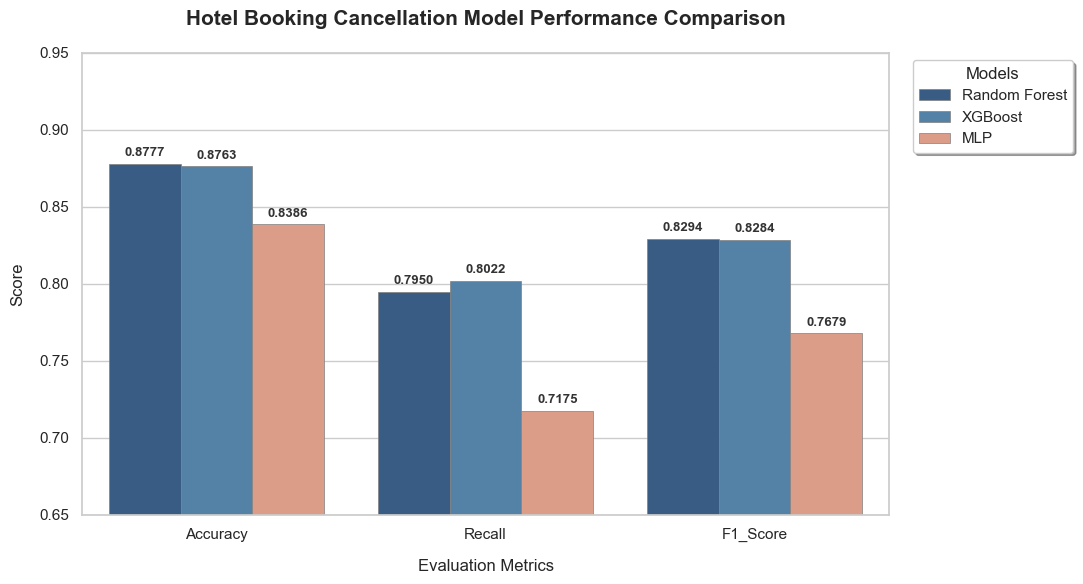

In [4]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정 다 필요 없음! 영어는 기본 폰트로 절대 안 깨집니다.
plt.rcParams['axes.unicode_minus'] = False 

# 1. 위치 기반 경로 설정 (graph.ipynb와 같은 폴더의 csv 수집)
current_dir = os.getcwd()
result_path = os.path.join(current_dir, '*_result.csv')
csv_files = glob.glob(result_path)

if not csv_files:
    print(f"🚨 Files not found in: {current_dir}")
else:
    # 2. 파일 읽어서 하나로 합치기
    df_list = [pd.read_csv(file) for file in csv_files]
    df_total = pd.concat(df_list, ignore_index=True)
    df_total = df_total.drop_duplicates(subset=['Model']).reset_index(drop=True)
    
    print("📊 Final Model Performance Table:")
    display(df_total.round(4))
    
    # 3. 그룹 막대그래프를 위한 포맷 변환 (Melt)
    df_melted = pd.melt(df_total, id_vars='Model', var_name='Metric', value_name='Score')
    
    # 4. 세련된 막대그래프 시각화 세팅
    plt.figure(figsize=(11, 6))
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    
    # 세련된 딥블루 & 네이비톤 컬러 팔레트
    custom_palette = ["#2b5c8f", "#4682b4", "#e9967a"]
    
    ax = sns.barplot(
        x='Metric', 
        y='Score', 
        hue='Model', 
        data=df_melted, 
        palette=custom_palette,
        edgecolor='gray',
        linewidth=0.5
    )
    
    plt.ylim(0.65, 0.95) 
    
    # 💡 [핵심] 한글을 다 빼고 영어로 직관적으로 변경
    plt.title('Hotel Booking Cancellation Model Performance Comparison', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Evaluation Metrics', fontsize=12, labelpad=12)
    plt.ylabel('Score', fontsize=12, labelpad=10)
    
    # 막대 위 수치 매핑
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.text(
                p.get_x() + p.get_width()/2., 
                height + 0.005, 
                f'{height:.4f}', 
                ha="center", 
                fontsize=9.5, 
                fontweight='bold',
                color='#333333'
            )
            
    plt.legend(title='Models', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()
    
    # 이미지 저장
    save_img_path = os.path.join(current_dir, 'total_model_comparison.png')
    plt.savefig(save_img_path, dpi=300)
    print(f"\n🎨 Graph saved successfully! ➡️ {save_img_path}")
    
    plt.show()